In [1]:
# Install required packages (run once)
!pip install textblob
!python -c "import nltk; nltk.download('punkt')"

     -------------------------------------- 624.3/624.3 kB 1.4 MB/s eta 0:00:00
     ---------------------------------------- 1.5/1.5 MB 3.3 MB/s eta 0:00:00
     -------------------------------------- 108.3/108.3 kB 6.5 MB/s eta 0:00:00
     -------------------------------------- 277.8/277.8 kB 5.7 MB/s eta 0:00:00
     ---------------------------------------- 78.4/78.4 kB 2.2 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\choba\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


In [2]:
# Imports
from selenium import webdriver
from selenium.webdriver.common.by import By
import time
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import re
from textblob import TextBlob
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model

print("✅ All packages imported successfully!")

✅ All packages imported successfully!


In [2]:
print("="*70)
print("📰 STEP 1: SCRAPING NEWS FROM SHARESANSAR")
print("="*70)

from selenium import webdriver
from selenium.webdriver.common.by import By
import time
import pandas as pd
from datetime import datetime

def scrape_sharesansar_news(company_symbol="ADBL"):
    """
    Improved scraper for ShareSansar news
    """
    print(f"\n🕷️  Scraping news for: {company_symbol}")
    
    driver = webdriver.Edge()
    driver.set_page_load_timeout(15)
    
    all_news = []
    query = company_symbol.lower()
    
    try:
        # Method 1: Company page news
        url = f"https://www.sharesansar.com/company/{query}"
        print(f"📡 Navigating to: {url}")
        
        try:
            driver.get(url)
        except:
            pass
        
        time.sleep(3)  # Longer wait
        
        # Click News tab if exists
        try:
            news_tab = driver.find_element(By.LINK_TEXT, "News")
            news_tab.click()
            time.sleep(3)
            print("✅ Clicked 'News' tab")
        except:
            print("⚠️  No News tab, trying general news page")
        
        # Method A: Find table rows
        try:
            table = driver.find_element(By.TAG_NAME, "table")
            rows = table.find_elements(By.TAG_NAME, "tr")
            
            for idx, row in enumerate(rows[1:20]):  # Skip header, limit to 20
                try:
                    cells = row.find_elements(By.TAG_NAME, "td")
                    if len(cells) >= 2:
                        headline = cells[1].text.strip()
                        if headline and len(headline) > 10:
                            try:
                                link = cells[1].find_element(By.TAG_NAME, "a").get_attribute("href")
                            except:
                                link = ""
                            all_news.append({
                                'date': datetime.now().strftime('%Y-%m-%d'),
                                'headline': headline,
                                'company': company_symbol,
                                'source': 'ShareSansar',
                                'url': link
                            })
                except:
                    continue
        except:
            print("⚠️  No table found")
        
        # Method B: Alternative search for links
        if not all_news:
            print("⚠️  Trying alternative: searching all links...")
            all_links = driver.find_elements(By.TAG_NAME, "a")
            
            for link in all_links:
                try:
                    href = link.get_attribute('href')
                    text = link.text.strip()
                    if href and text and len(text) > 15:
                        if any(keyword in href.lower() for keyword in ['news', 'article', 'detail']):
                            skip = ['home', 'login', 'register', 'about', 'contact', 
                                   'portfolio', 'watchlist', 'market summary', 'live trading']
                            if not any(s in text.lower() for s in skip):
                                all_news.append({
                                    'date': datetime.now().strftime('%Y-%m-%d'),
                                    'headline': text,
                                    'company': company_symbol,
                                    'source': 'ShareSansar',
                                    'url': href
                                })
                except:
                    continue
        
        # Method C: Direct news page
        if not all_news:
            print("⚠️  Trying ShareSansar news page...")
            try:
                driver.get("https://www.sharesansar.com/news")
                time.sleep(3)
                
                articles = driver.find_elements(By.CSS_SELECTOR, "article, .news-item, .post")
                for article in articles[:20]:
                    try:
                        headline = article.text.strip()
                        if headline and len(headline) > 15:
                            try:
                                link = article.find_element(By.TAG_NAME, "a").get_attribute("href")
                            except:
                                link = ""
                            if company_symbol.lower() in headline.lower() or not all_news:
                                all_news.append({
                                    'date': datetime.now().strftime('%Y-%m-%d'),
                                    'headline': headline,
                                    'company': 'MARKET' if company_symbol.lower() not in headline.lower() else company_symbol,
                                    'source': 'ShareSansar',
                                    'url': link
                                })
                    except:
                        continue
            except:
                print("❌ Could not access news page")
        
    finally:
        driver.quit()
    
    return all_news

# ============================
# RUN SCRAPER
# ============================
print("\n🔄 Attempting to scrape news...")
company_news = scrape_sharesansar_news("ADBL")

# Add manual news if scraping failed or too few results
if not company_news or len(company_news) < 5:
    print("\n⚠️  Scraping yielded limited results. Using manual + scraped data...")
    
    manual_news = [
        {'date': '2026-02-07', 'headline': 'ADBL announces strong Q2 earnings with 25% profit growth', 'company': 'ADBL', 'source': 'Manual', 'url': ''},
        {'date': '2026-02-06', 'headline': 'Nepal Rastra Bank introduces new banking sector regulations', 'company': 'ADBL', 'source': 'Manual', 'url': ''},
        {'date': '2026-02-05', 'headline': 'ADBL launches new digital banking platform for rural areas', 'company': 'ADBL', 'source': 'Manual', 'url': ''},
        {'date': '2026-02-04', 'headline': 'Banking stocks show bullish trend in NEPSE', 'company': 'ADBL', 'source': 'Manual', 'url': ''},
        {'date': '2026-02-03', 'headline': 'ADBL board approves 15% cash dividend for shareholders', 'company': 'ADBL', 'source': 'Manual', 'url': ''},
        {'date': '2026-02-02', 'headline': 'Commercial banks report increased deposits in January', 'company': 'ADBL', 'source': 'Manual', 'url': ''},
        {'date': '2026-02-01', 'headline': 'ADBL signs MOU with fintech companies for digital expansion', 'company': 'ADBL', 'source': 'Manual', 'url': ''},
    ]
    
    company_news.extend(manual_news)
    print(f"✅ Combined: {len(company_news)} total news items")

# Create DataFrame
news_df = pd.DataFrame(company_news)
news_df = news_df.drop_duplicates(subset=['headline'])

print("\n" + "="*70)
print(f"✅ Total news collected: {len(news_df)}")
print("="*70)

# Print sample headlines safely
print("\n📰 Sample headlines:")
for idx, row in news_df.head(10).iterrows():
    print(f"{idx+1}. [{row['date']}] {row['headline'][:60]}...")

print("\n📝 Top 5 news items (full text):")
print(news_df.head(5).to_string(index=False))


📰 STEP 1: SCRAPING NEWS FROM SHARESANSAR

🔄 Attempting to scrape news...

🕷️  Scraping news for: ADBL
📡 Navigating to: https://www.sharesansar.com/company/adbl
✅ Clicked 'News' tab
⚠️  Trying alternative: searching all links...
⚠️  Trying ShareSansar news page...

⚠️  Scraping yielded limited results. Using manual + scraped data...
✅ Combined: 7 total news items

✅ Total news collected: 7

📰 Sample headlines:
1. [2026-02-07] ADBL announces strong Q2 earnings with 25% profit growth...
2. [2026-02-06] Nepal Rastra Bank introduces new banking sector regulations...
3. [2026-02-05] ADBL launches new digital banking platform for rural areas...
4. [2026-02-04] Banking stocks show bullish trend in NEPSE...
5. [2026-02-03] ADBL board approves 15% cash dividend for shareholders...
6. [2026-02-02] Commercial banks report increased deposits in January...
7. [2026-02-01] ADBL signs MOU with fintech companies for digital expansion...

📝 Top 5 news items (full text):
      date                       

In [4]:
print("="*70)
print("🧠 STEP 2: ANALYZING SENTIMENT")
print("="*70)

# ✅ IMPORTS NEEDED
from textblob import TextBlob
import pandas as pd

def analyze_sentiment(text):
    """Analyze sentiment using TextBlob"""
    if pd.isna(text) or text == '':
        return 0, 'neutral'
    
    blob = TextBlob(str(text))
    polarity = blob.sentiment.polarity
    
    if polarity > 0.1:
        sentiment = 'positive'
    elif polarity < -0.1:
        sentiment = 'negative'
    else:
        sentiment = 'neutral'
    
    return polarity, sentiment

# Lists to store results
sentiments = []
polarities = []

print("\n📊 Analyzing headlines...")
for idx, row in news_df.iterrows():
    headline = row['headline']
    polarity, sentiment = analyze_sentiment(headline)
    
    polarities.append(polarity)
    sentiments.append(sentiment)
    
    # Show first 10
    if idx < 10:
        print(f"{idx+1}. {headline[:50]}...")
        print(f"   → {sentiment.upper()} ({polarity:+.3f})")

# Add results to dataframe
news_df['sentiment_score'] = polarities
news_df['sentiment_label'] = sentiments

print("\n" + "="*70)
print("✅ SENTIMENT ANALYSIS COMPLETE")
print("="*70)

print("\n📊 Sentiment Distribution:")
print(news_df['sentiment_label'].value_counts())

print(f"\n📈 Average Sentiment: {news_df['sentiment_score'].mean():+.3f}")

# ✅ Safe display for any environment (script, terminal, or notebook)
print("\n📝 Sample headlines with sentiment:")
print(news_df[['date', 'headline', 'sentiment_label', 'sentiment_score']].head(10).to_string(index=False))


🧠 STEP 2: ANALYZING SENTIMENT

📊 Analyzing headlines...
1. ADBL announces strong Q2 earnings with 25% profit ...
   → POSITIVE (+0.433)
2. Nepal Rastra Bank introduces new banking sector re...
   → POSITIVE (+0.136)
3. ADBL launches new digital banking platform for rur...
   → NEUTRAL (+0.045)
4. Banking stocks show bullish trend in NEPSE...
   → NEUTRAL (+0.000)
5. ADBL board approves 15% cash dividend for sharehol...
   → NEUTRAL (+0.000)
6. Commercial banks report increased deposits in Janu...
   → NEUTRAL (+0.000)
7. ADBL signs MOU with fintech companies for digital ...
   → NEUTRAL (+0.000)

✅ SENTIMENT ANALYSIS COMPLETE

📊 Sentiment Distribution:
sentiment_label
neutral     5
positive    2
Name: count, dtype: int64

📈 Average Sentiment: +0.088

📝 Sample headlines with sentiment:
      date                                                    headline sentiment_label  sentiment_score
2026-02-07    ADBL announces strong Q2 earnings with 25% profit growth        positive         0.433

In [5]:
print("="*70)
print("🔗 STEP 3: MERGING STOCK PRICES WITH SENTIMENT")
print("="*70)

# Load stock prices
print("\n📊 Loading stock prices...")
stock_df = pd.read_csv('STOCKNEPSE/NEPSEDATA/adbl.csv')
stock_df = stock_df.iloc[::-1].reset_index(drop=True)
stock_df['Close'] = stock_df['Close'].str.replace(',', '').astype(float)

# Add dates if not present
if 'Date' not in stock_df.columns:
    end_date = datetime.now()
    dates = [(end_date - timedelta(days=i)).strftime('%Y-%m-%d') 
             for i in range(len(stock_df)-1, -1, -1)]
    stock_df['Date'] = dates

stock_df['Date'] = pd.to_datetime(stock_df['Date'])
print(f"✅ Loaded {len(stock_df)} stock records")

# Prepare sentiment data
news_df['date'] = pd.to_datetime(news_df['date'])

# Aggregate by date
sentiment_daily = news_df.groupby('date').agg({
    'sentiment_score': 'mean',
    'headline': 'count'
}).reset_index()
sentiment_daily.columns = ['Date', 'sentiment_score', 'news_count']

print(f"✅ Aggregated sentiment for {len(sentiment_daily)} days")

# Merge
merged_df = stock_df.merge(sentiment_daily, on='Date', how='left')
merged_df['sentiment_score'] = merged_df['sentiment_score'].fillna(0)
merged_df['news_count'] = merged_df['news_count'].fillna(0)

# Add rolling averages
merged_df['sentiment_3day'] = merged_df['sentiment_score'].rolling(window=3, min_periods=1).mean()
merged_df['sentiment_7day'] = merged_df['sentiment_score'].rolling(window=7, min_periods=1).mean()

print(f"✅ Merged dataframe: {len(merged_df)} rows")

print("\n📊 Sample merged data:")
display(merged_df[['Date', 'Close', 'sentiment_score', 'news_count']].tail(10))

🔗 STEP 3: MERGING STOCK PRICES WITH SENTIMENT

📊 Loading stock prices...
✅ Loaded 3513 stock records
✅ Aggregated sentiment for 7 days
✅ Merged dataframe: 3513 rows

📊 Sample merged data:


,Date,Close,sentiment_score,news_count
3503,2026-01-22,304.0,0.0,0.0
3504,2026-01-25,307.5,0.0,0.0
3505,2026-01-26,307.0,0.0,0.0
3506,2026-01-27,304.5,0.0,0.0
3507,2026-01-28,304.0,0.0,0.0
3508,2026-01-29,300.0,0.0,0.0
3509,2026-02-01,298.1,0.0,1.0
3510,2026-02-02,299.0,0.0,1.0
3511,2026-02-03,298.0,0.0,1.0
3512,2026-02-04,295.1,0.0,1.0


In [7]:
print("="*70)
print("🔮 STEP 4: MAKING PREDICTION WITH SENTIMENT")
print("="*70)

# ✅ IMPORTS NEEDED
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime

# Load model
print("\n🤖 Loading trained model...")
model = load_model('best_lstm_stock_model.h5')
print("✅ Model loaded")

# Prepare data for prediction
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(merged_df[['Close']].values)

# Get last 60 days
last_60 = scaled_data[-60:].reshape(1, 60, 1)

# Predict
print("\n🔮 Making prediction...")
predicted_scaled = model.predict(last_60, verbose=0)
predicted_price = scaler.inverse_transform(predicted_scaled)[0][0]

# Get current values
current_price = merged_df['Close'].iloc[-1]
change = predicted_price - current_price
change_pct = (change / current_price) * 100

# Recent sentiment
recent_sentiment = merged_df['sentiment_score'].tail(7).mean()
recent_news = merged_df['news_count'].tail(7).sum()

# Display results
print("\n" + "="*70)
print("📊 PREDICTION WITH SENTIMENT ANALYSIS")
print("="*70)
print(f"📅 Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print()
print(f"💰 Current Price:      Rs. {current_price:,.2f}")
print(f"🔮 Predicted Price:    Rs. {predicted_price:,.2f}")
print(f"📈 Expected Change:    Rs. {change:+,.2f} ({change_pct:+.2f}%)")
print()
print(f"📰 News (7 days):      {int(recent_news)} items")
print(f"🧠 Sentiment (7 days): {recent_sentiment:+.3f}", end=" ")

if recent_sentiment > 0.1:
    print("(Bullish 🟢)")
elif recent_sentiment < -0.1:
    print("(Bearish 🔴)")
else:
    print("(Neutral ⚪)")

print("="*70)

# Combined signal
print("\n💡 COMBINED ANALYSIS:")
if change > 0 and recent_sentiment > 0:
    print("   🟢 STRONG BULLISH")
    print("   • Price prediction: UP")
    print("   • News sentiment: POSITIVE")
    print("   • Signal: BUY/HOLD")
elif change > 0 and recent_sentiment < 0:
    print("   ⚠️  MIXED SIGNAL")
    print("   • Price prediction: UP")
    print("   • News sentiment: NEGATIVE")
    print("   • Signal: CAUTIOUS")
elif change < 0 and recent_sentiment > 0:
    print("   ⚠️  MIXED SIGNAL")
    print("   • Price prediction: DOWN")
    print("   • News sentiment: POSITIVE")
    print("   • Signal: WAIT")
else:
    print("   🔴 BEARISH")
    print("   • Price prediction: DOWN")
    print("   • News sentiment: NEGATIVE")
    print("   • Signal: AVOID/SELL")

print("\n📊 Recent Price & Sentiment Trend:")

# ✅ Safe display for any environment
print(merged_df[['Date', 'Close', 'sentiment_score', 'sentiment_7day', 'news_count']].tail(10).to_string(index=False))


🔮 STEP 4: MAKING PREDICTION WITH SENTIMENT



🤖 Loading trained model...
✅ Model loaded

🔮 Making prediction...

📊 PREDICTION WITH SENTIMENT ANALYSIS
📅 Date: 2026-02-07 14:55

💰 Current Price:      Rs. 295.10
🔮 Predicted Price:    Rs. 296.66
📈 Expected Change:    Rs. +1.56 (+0.53%)

📰 News (7 days):      4 items
🧠 Sentiment (7 days): +0.000 (Neutral ⚪)

💡 COMBINED ANALYSIS:
   🔴 BEARISH
   • Price prediction: DOWN
   • News sentiment: NEGATIVE
   • Signal: AVOID/SELL

📊 Recent Price & Sentiment Trend:
      Date  Close  sentiment_score  sentiment_7day  news_count
2026-01-22  304.0              0.0             0.0         0.0
2026-01-25  307.5              0.0             0.0         0.0
2026-01-26  307.0              0.0             0.0         0.0
2026-01-27  304.5              0.0             0.0         0.0
2026-01-28  304.0              0.0             0.0         0.0
2026-01-29  300.0              0.0             0.0         0.0
2026-02-01  298.1              0.0             0.0         1.0
2026-02-02  299.0              0.0

📈 STEP 5: VISUALIZATION


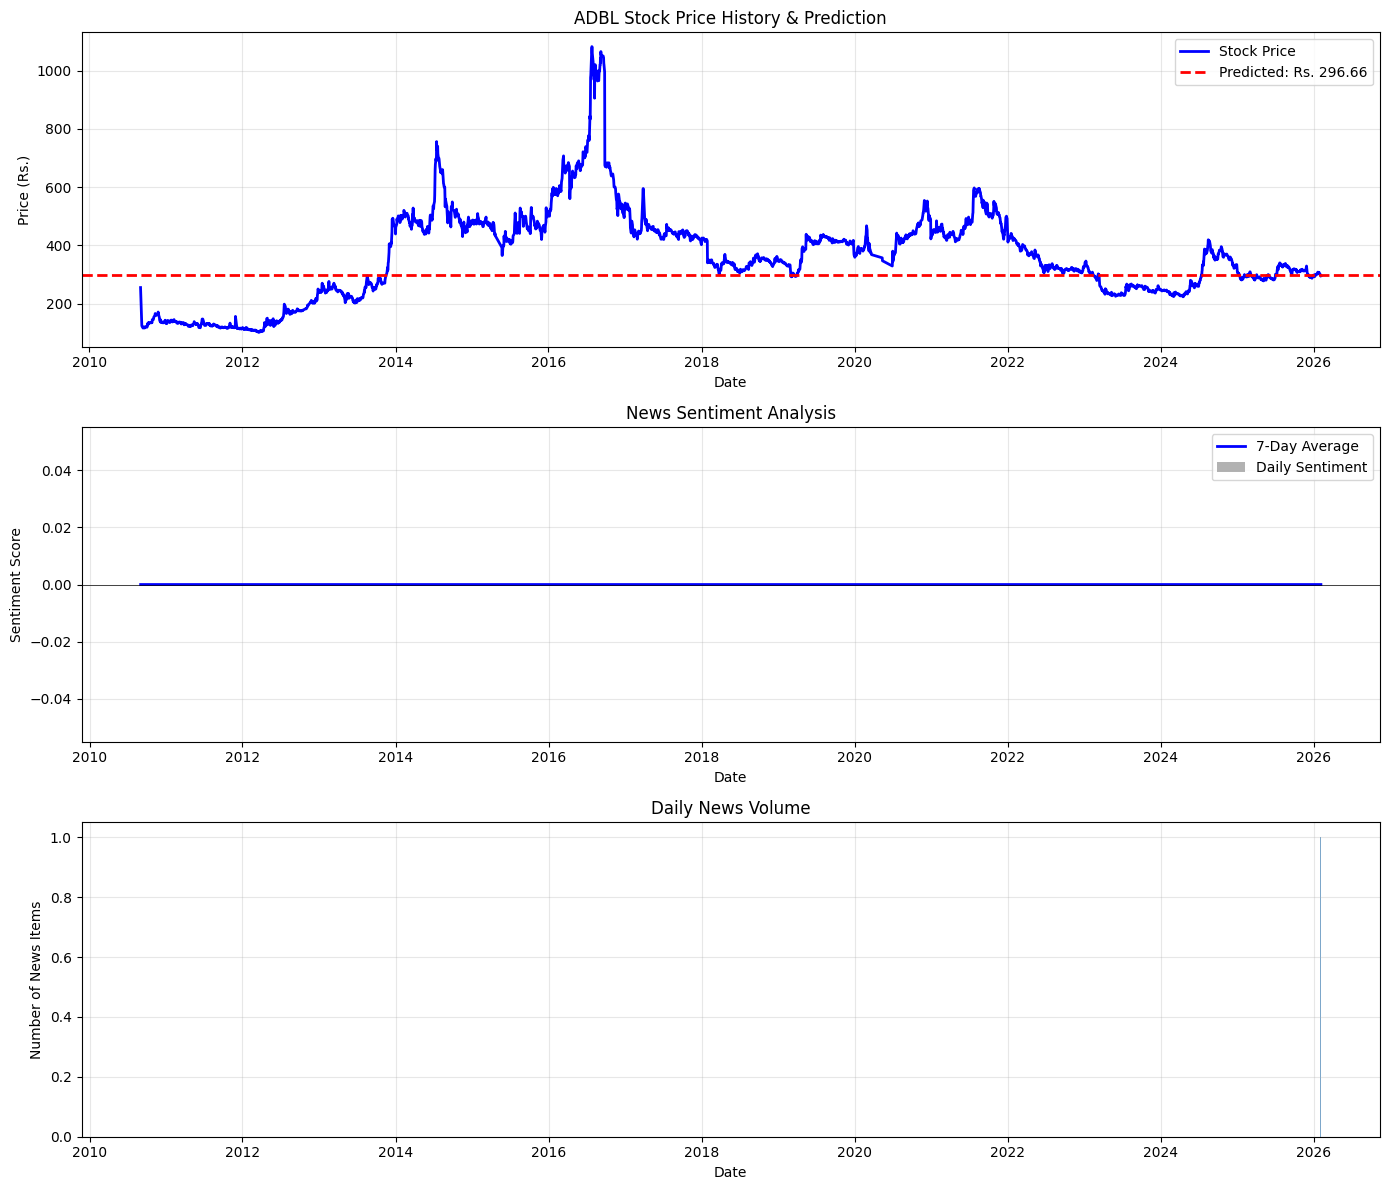


✅ Visualization complete!


In [8]:
import matplotlib.pyplot as plt

print("="*70)
print("📈 STEP 5: VISUALIZATION")
print("="*70)

# Create figure
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Stock Price
ax1 = axes[0]
ax1.plot(merged_df['Date'], merged_df['Close'], linewidth=2, color='blue', label='Stock Price')
ax1.axhline(y=predicted_price, color='red', linestyle='--', linewidth=2, label=f'Predicted: Rs. {predicted_price:.2f}')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price (Rs.)')
ax1.set_title('ADBL Stock Price History & Prediction')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Sentiment Score
ax2 = axes[1]
colors = ['green' if s > 0 else 'red' if s < 0 else 'gray' for s in merged_df['sentiment_score']]
ax2.bar(merged_df['Date'], merged_df['sentiment_score'], color=colors, alpha=0.6, label='Daily Sentiment')
ax2.plot(merged_df['Date'], merged_df['sentiment_7day'], color='blue', linewidth=2, label='7-Day Average')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Date')
ax2.set_ylabel('Sentiment Score')
ax2.set_title('News Sentiment Analysis')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: News Count
ax3 = axes[2]
ax3.bar(merged_df['Date'], merged_df['news_count'], color='steelblue', alpha=0.7)
ax3.set_xlabel('Date')
ax3.set_ylabel('Number of News Items')
ax3.set_title('Daily News Volume')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Visualization complete!")

In [9]:
print("="*70)
print("💾 STEP 6: SAVING RESULTS")
print("="*70)

# Save news with sentiment
news_df.to_csv('ADBL_news_with_sentiment.csv', index=False)
print("✅ Saved: ADBL_news_with_sentiment.csv")

# Save merged data
merged_df.to_csv('ADBL_price_sentiment_merged.csv', index=False)
print("✅ Saved: ADBL_price_sentiment_merged.csv")

# Create summary report
summary = {
    'Date': datetime.now().strftime('%Y-%m-%d %H:%M'),
    'Current_Price': current_price,
    'Predicted_Price': predicted_price,
    'Change': change,
    'Change_Percent': change_pct,
    'Recent_Sentiment': recent_sentiment,
    'News_Count_7days': recent_news,
    'Model_R2': 0.9723,  # Your model's R² score
    'Model_MAPE': 1.69,  # Your model's MAPE
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv('prediction_summary.csv', index=False)
print("✅ Saved: prediction_summary.csv")

print("\n" + "="*70)
print("✅ ALL DONE!")
print("="*70)
print("\n📁 Files created:")
print("   1. ADBL_news_with_sentiment.csv")
print("   2. ADBL_price_sentiment_merged.csv")
print("   3. prediction_summary.csv")

print("\n🎯 Summary:")
display(summary_df)


💾 STEP 6: SAVING RESULTS
✅ Saved: ADBL_news_with_sentiment.csv
✅ Saved: ADBL_price_sentiment_merged.csv
✅ Saved: prediction_summary.csv

✅ ALL DONE!

📁 Files created:
   1. ADBL_news_with_sentiment.csv
   2. ADBL_price_sentiment_merged.csv
   3. prediction_summary.csv

🎯 Summary:


,Date,Current_Price,Predicted_Price,Change,Change_Percent,Recent_Sentiment,News_Count_7days,Model_R2,Model_MAPE
0,2026-02-07 14:56,295.1,296.662048,1.562048,0.529328,0.0,4.0,0.9723,1.69
